# Spaceship Titanic

## Задача

_Необходимо создать модель, способную предсказать: достигнет пассажир другое измерений._

## Импорт библиотек и файлов

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [121]:
df_test_target = pd.read_csv("../data/sample_submission.csv")
df_train = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")

In [122]:
df_test_target.head()

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


In [123]:
df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [124]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [125]:
df_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [126]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


## Обозначения

1. `PassengerId` - уникальный **идентификатор** каждого пассажира.
2. `HomePlanet` - **планета**, с которой выехал пассажир.
3. `CryoSleep` - **идентификатор** выбора креосна пассажира во время поездки.
4. `Cabin` - **номер каюты** пассажира.
5. `Destination` - **планета назначения**, на которую отправляется человек.
6. `Age` - **возраст** пассажира.
7. `VIP` - **идентификатор** выбора VIP условий пассажира во время поездки.
8. `RoomService` - **сумма**, которую потратил пассажир на обслуживание в номере во время поездки.
9. `FoodCourt` - **сумма**, которую потратил пассажир на питание во время поездки.
10. `ShoppingMall` - **сумма**, которую потратил пассажир на покупки в торговом центре корабля.
11. `Spa` - **сумма**, которую пассажир потратил на SPA-услуги во время поездки.
12. `VRDeck` - **сумма**, которую пассажир потратил на развлечения во время поездки.
13. `Name` - **Имя** пассажира.

14. `Transported` - целевая переменная; доставлен пассажир или нет в пункт назначения.

## Предварительная обработка и исследование данных

### Работа с выбросами

In [127]:
df_train.corr(numeric_only=True)["Transported"][:-1]

Age            -0.075026
RoomService    -0.244611
FoodCourt       0.046566
ShoppingMall    0.010141
Spa            -0.221131
VRDeck         -0.207075
Name: Transported, dtype: float64

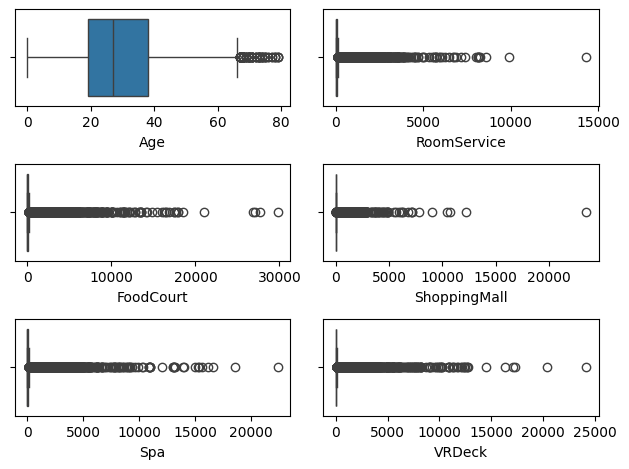

In [128]:
fig, axis = plt.subplots(3, 2)
sns.boxplot(data=df_train, x="Age", ax=axis[0][0])
sns.boxplot(data=df_train, x="RoomService", ax=axis[0][1])
sns.boxplot(data=df_train, x="FoodCourt", ax=axis[1][0])
sns.boxplot(data=df_train, x="ShoppingMall", ax=axis[1][1])
sns.boxplot(data=df_train, x="Spa", ax=axis[2][0])
sns.boxplot(data=df_train, x="VRDeck", ax=axis[2][1])
plt.tight_layout()

Распределение признака `Age` выглядит естественно, а у признаков трат распределение имеет большое количество выбросов справа, создавая тем самым "хвост".

Так как основная доля наблюдение располагается в районе нуля - применять `np.nanpercentile` нельзя, лучше применить `log1p`, чтобы вытянуть хвост и не допустить бесконечности.

Для будущих исследований создадим копию датафрейма.

In [129]:
waste_money_columns = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

for col in waste_money_columns:
    df_train[col] = np.log1p(df_train[col])
    df_test[col] = np.log1p(df_test[col])

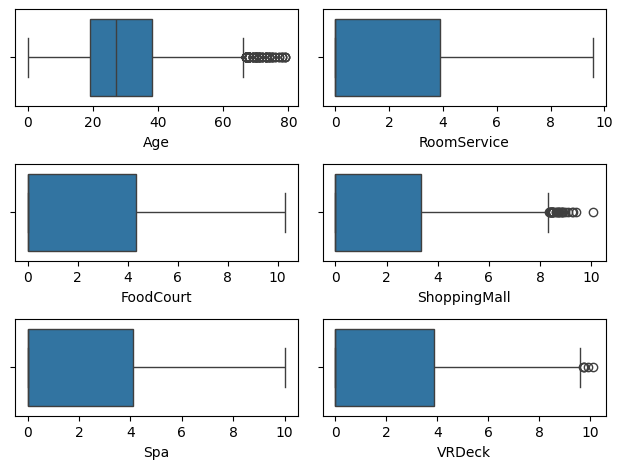

In [130]:
fig, axis = plt.subplots(3, 2)
sns.boxplot(data=df_train, x="Age", ax=axis[0][0])
sns.boxplot(data=df_train, x="RoomService", ax=axis[0][1])
sns.boxplot(data=df_train, x="FoodCourt", ax=axis[1][0])
sns.boxplot(data=df_train, x="ShoppingMall", ax=axis[1][1])
sns.boxplot(data=df_train, x="Spa", ax=axis[2][0])
sns.boxplot(data=df_train, x="VRDeck", ax=axis[2][1])
plt.tight_layout()

In [131]:
df_train.corr(numeric_only=True)["Transported"][:-1]

Age            -0.075026
RoomService    -0.362803
FoodCourt      -0.136035
ShoppingMall   -0.180193
Spa            -0.367705
VRDeck         -0.343462
Name: Transported, dtype: float64

С некоторыми признаками корреляция по целевой переменной уменьшилась в два раза, а с некоторыми поменялся знак.

__Вывод__: чем меньше трат - тем выше шанс быть перенесённым на другую планету.

### Работа с пропусками

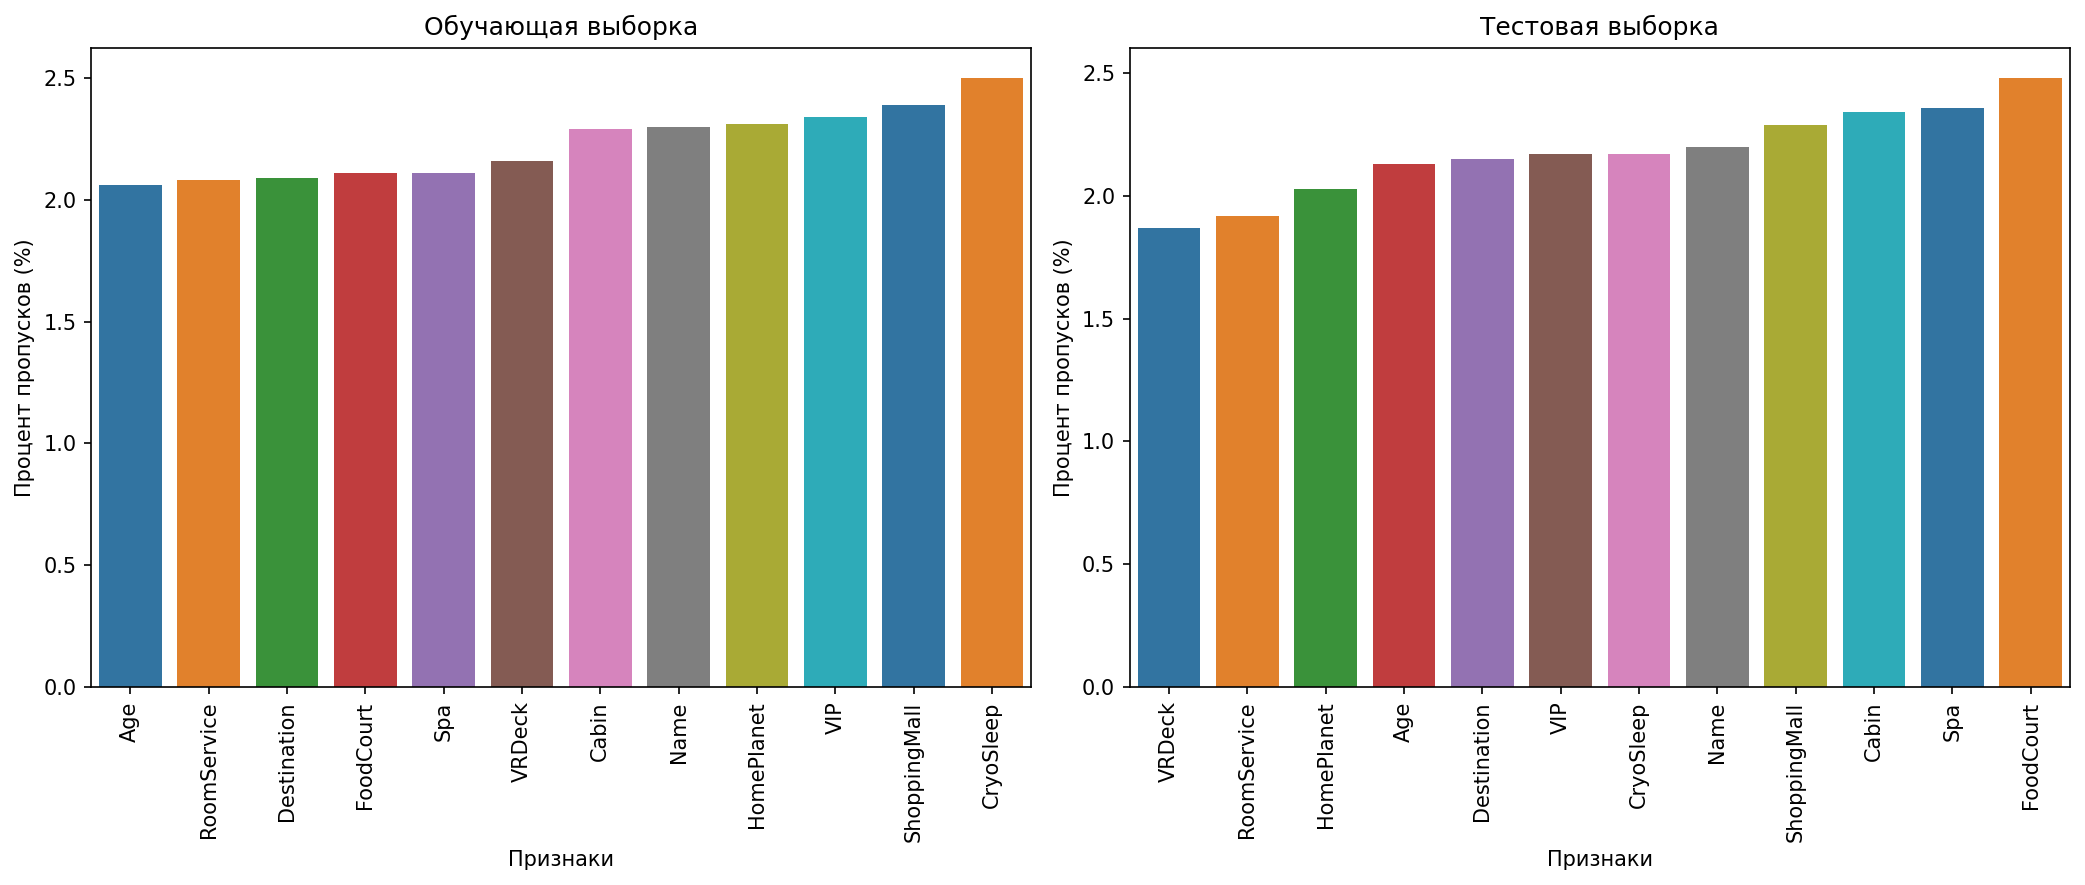

In [132]:
from modules.utils import show_missing_data

show_missing_data(df_train, df_test)

Процент пропущенных значений небольшой, однако в целях сохранения информативности необходимо заполнить пропуски.

#### `Age`

<Axes: xlabel='Age', ylabel='Count'>

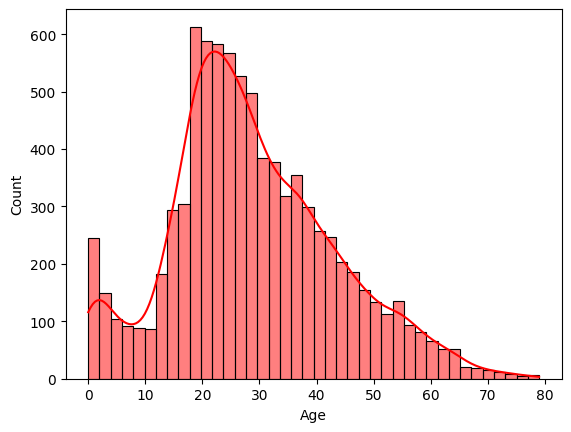

In [133]:
sns.histplot(df_train["Age"], bins=40, kde=True, color="red", edgecolor="black")

"Хвост" уходит вправо из-за редких пожилых пассажиров, поэтому для заполнения пропусков лучше использовать медианное значение. 

In [134]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())
df_test["Age"] = df_test["Age"].fillna(df_train["Age"].median())

#### `RoomService`

<Axes: xlabel='RoomService', ylabel='Count'>

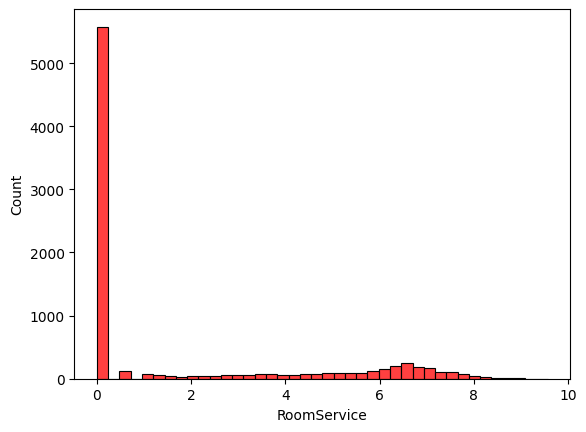

In [135]:
sns.histplot(data=df_train, x="RoomService", bins=40, color="red", edgecolor="black")

Большинство людей не тратили деньги на обслуживание в номере, медианное значение равно нулю. Исходя из логики, можно заполнить пропуски нулём для людей, находящихся в креокамере, а также медианой.

In [136]:
from modules.utils import percent_missing

percent_missing(df_train, "RoomService")

"Процент пропущенных значений в 'RoomService': 2.08%"

In [137]:
for df in [df_train, df_test]:
    df.loc[df["RoomService"].isna() & df["CryoSleep"], "RoomService"] = 0

In [138]:
for df in [df_train, df_test]:
    df.loc[(df["RoomService"].isna()) & (df["CryoSleep"] == False), "RoomService"] = df_train["RoomService"].median()

In [139]:
percent_missing(df_train, "RoomService")

"Процент пропущенных значений в 'RoomService': 0.02%"

In [140]:
percent_missing(df_test, "RoomService")

"Процент пропущенных значений в 'RoomService': 0.02%"

#### `Destination`

In [141]:
print(f"Список мест, куда прибывают пассажиры: {df_train["Destination"].unique()}")

Список мест, куда прибывают пассажиры: ['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e' nan]


In [142]:
percent_missing(df_train, "Destination")

"Процент пропущенных значений в 'Destination': 2.09%"

In [143]:
percent_missing(df_test, "Destination")

"Процент пропущенных значений в 'Destination': 2.15%"

In [144]:
Destination_map = df_train.groupby("HomePlanet", dropna=False)["Destination"].apply(lambda x: x.mode()[0]).to_dict()

In [145]:
Destination_map

{'Earth': 'TRAPPIST-1e',
 'Europa': 'TRAPPIST-1e',
 'Mars': 'TRAPPIST-1e',
 nan: 'TRAPPIST-1e'}

Заполнение заполнение самым популярным значением через признак `HomePlanet` не даст нужный результат: мы получаем глобальную моду.
В документации сказано, что первые 4 цифры `PassengerId` - группа, с которой путешествует пассажир.

In [146]:
df_train["Group"] = df_train["PassengerId"].apply(lambda x: x.split("_")[0])
df_test["Group"] = df_test["PassengerId"].apply(lambda x: x.split("_")[0])

group_dest_map = pd.concat([df_train, df_test]).dropna(subset="Destination").groupby("Group")["Destination"].first().to_dict()

for df in [df_train, df_test]:
    df["Destination"] = df["Destination"].fillna(df["Group"].map(group_dest_map))

In [147]:
percent_missing(df_train, "Destination")

"Процент пропущенных значений в 'Destination': 1.18%"

In [148]:
percent_missing(df_test, "Destination")

"Процент пропущенных значений в 'Destination': 1.19%"

Возможно, пассажир с пропуском в `Destination` летел один, либо у всех в группе был `nan`. Заполнение глобальной модой не сильно повлияет на результат.

In [149]:
for df in [df_train, df_test]:
    df["Destination"] = df["Destination"].fillna(df["Destination"].mode()[0])

#### `ShoppingMall`, `RoomService`, `FoodCourt`, `VRDeck`, `Spa`

Данные признаки представляют собой траты пассажиров на различные услуги, предоставляемые на корабле. Логично, что находясь в креосне - пассажир ничего не потратит; также ключевую роль играет возраст - ребёнок не может потратить много, бодрствующие пассажиры тратят деньги в зависимости от своей возрастной категории.

<Axes: xlabel='Age', ylabel='TotalSpend'>

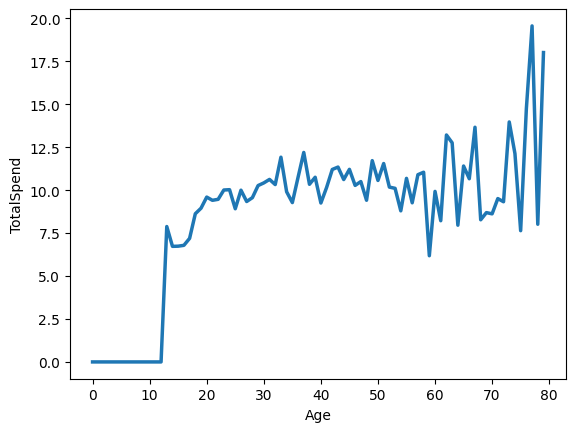

In [150]:
df_train["TotalSpend"] = df_train[waste_money_columns].sum(axis=1)
df_test["TotalSpend"] = df_test[waste_money_columns].sum(axis=1)

sns.lineplot(data=df_train, x="Age", y="TotalSpend", estimator="mean", errorbar=None, lw=2.5)

На графике видна зависимость денежных трат от возраста. Пассажиры возрастной группы до 12 лет не тратят деньги.

In [151]:
unfilled_spend_cols = ["ShoppingMall", "RoomService", "FoodCourt", "VRDeck", "Spa"]

print("Процент пропущенных данных в тренировочной выборке")
for col in unfilled_spend_cols:
    print(percent_missing(df_train, col))

Процент пропущенных данных в тренировочной выборке
Процент пропущенных значений в 'ShoppingMall': 2.39%
Процент пропущенных значений в 'RoomService': 0.02%
Процент пропущенных значений в 'FoodCourt': 2.11%
Процент пропущенных значений в 'VRDeck': 2.16%
Процент пропущенных значений в 'Spa': 2.11%


In [152]:
print("Процент пропущенных данных в тестовой выборке")
for col in unfilled_spend_cols:
    print(percent_missing(df_test, col))

Процент пропущенных данных в тестовой выборке
Процент пропущенных значений в 'ShoppingMall': 2.29%
Процент пропущенных значений в 'RoomService': 0.02%
Процент пропущенных значений в 'FoodCourt': 2.48%
Процент пропущенных значений в 'VRDeck': 1.87%
Процент пропущенных значений в 'Spa': 2.36%


In [153]:
for col in unfilled_spend_cols:
    for df in [df_train, df_test]:
        zero_mask = (df["CryoSleep"] == True) | (df["Age"] <= 12)
        df.loc[zero_mask & df[col].isna(), col] = 0

    col_median = df_train.loc[df_train["CryoSleep"] == False, col].median()
    
    for df in [df_train, df_test]:
        df[col] = df[col].fillna(col_median)

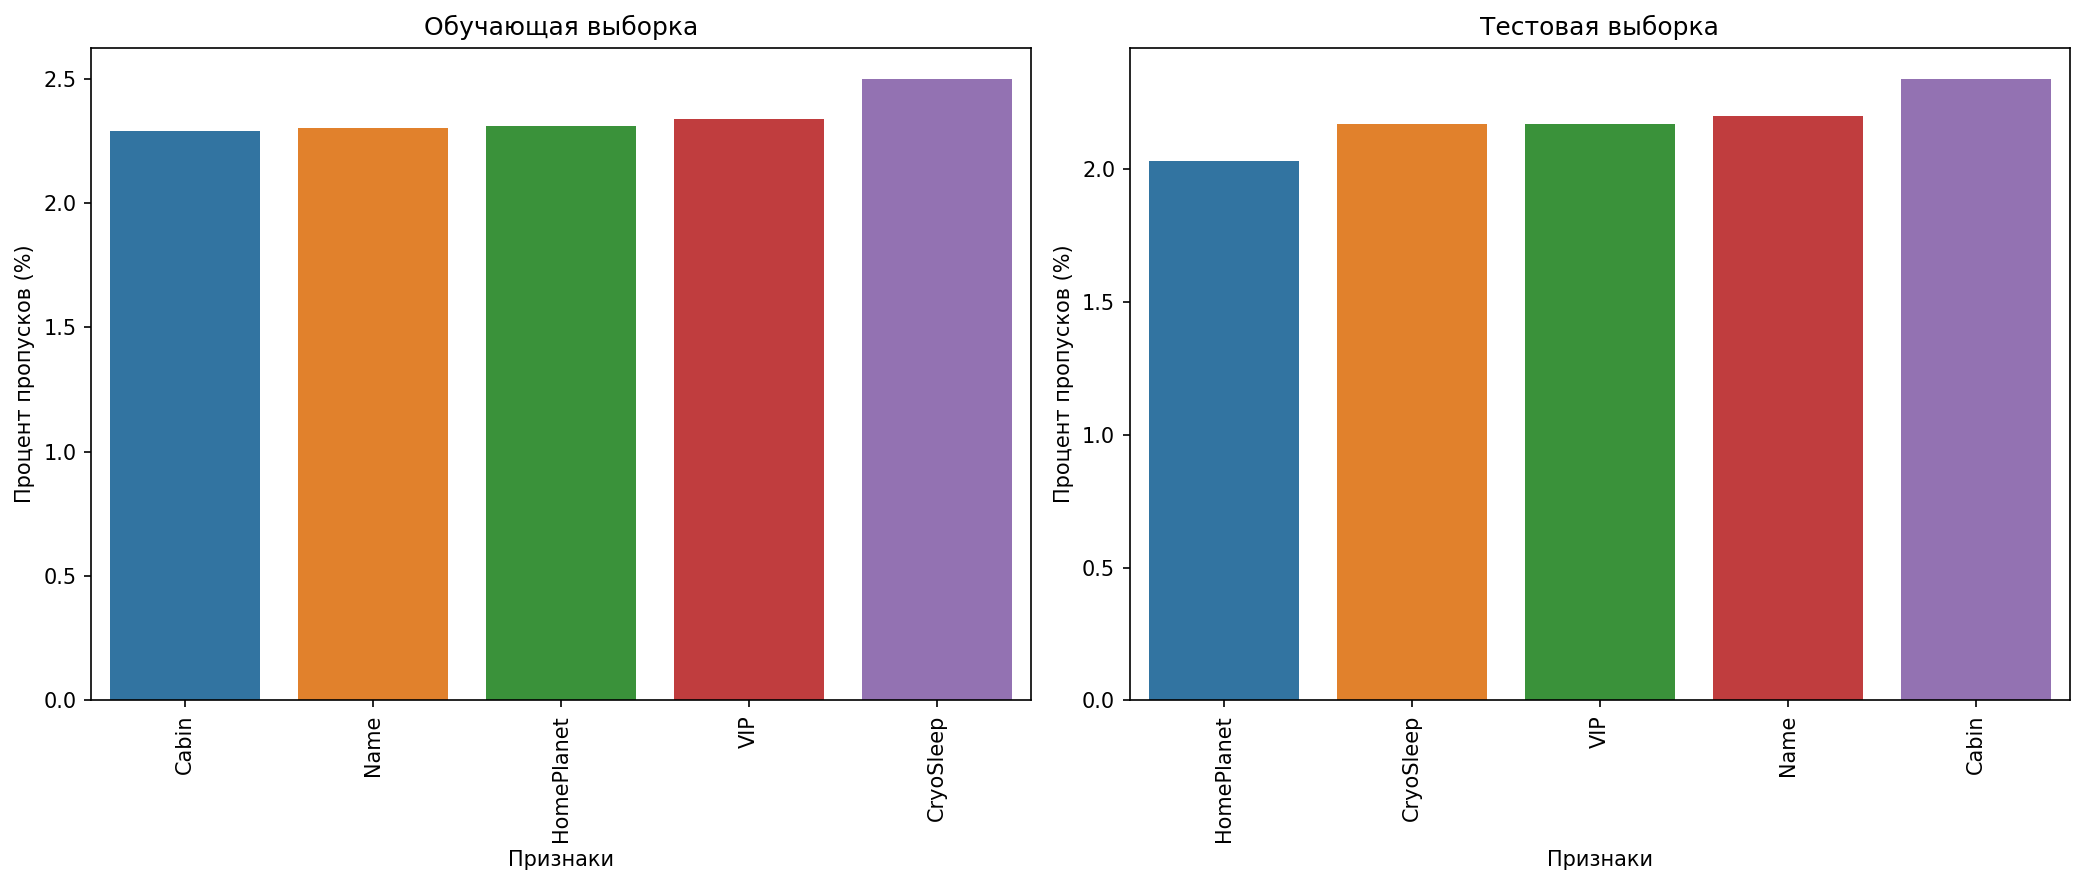

In [154]:
show_missing_data(df_train, df_test)

#### `Name`

In [155]:
df_train["Name"].nunique()

8473

In [156]:
df_train["Name"].head()

0      Maham Ofracculy
1         Juanna Vines
2        Altark Susent
3         Solam Susent
4    Willy Santantines
Name: Name, dtype: object

Признак `Name` содержит много уникальных значений, однако из него мы можем извлечь другие - фамилия `Surname` и размер семьи `Family_size`.

In [157]:
for df in [df_train, df_test]:
    df["Surname"] = df["Name"].apply(lambda x: str(x).split()[-1] if pd.notna(x) else np.nan)
    df["Family_group"] = np.where(
        df["Surname"].notna(),
        df["Surname"].astype(str) + '_' + df["Group"].astype(str),
        np.nan
    )

Family_size_map = pd.concat([df_train, df_test])["Family_group"].value_counts().to_dict()

for df in [df_train, df_test]:
    df["Family_size"] = df["Family_group"].map(Family_size_map).fillna(1)

for df in [df_train, df_test]:
    df.drop(["Name", "Surname", "Family_group"], axis=1, inplace=True)

#### `Cabin`

Номер каюты связан с группой `Group` пассажиров, которая отправляется из одной планеты `HomePlanet`. Сам по себе признак содержит внутри слишком много уникальных значений, поэтому лучшим решением будет разделить его на другие: палуба `Deck`, номер `Num`, сторона корабля `Side`

In [158]:
percent_missing(df_train, "Cabin")

"Процент пропущенных значений в 'Cabin': 2.29%"

In [159]:
percent_missing(df_test, "Cabin")

"Процент пропущенных значений в 'Cabin': 2.34%"

In [160]:
df_train["Cabin"].head()

0    B/0/P
1    F/0/S
2    A/0/S
3    A/0/S
4    F/1/S
Name: Cabin, dtype: object

In [161]:
for df in [df_train, df_test]:
    df["Deck"] = df["Cabin"].apply(lambda x: str(x).split("/")[0] if pd.notna(x) else np.nan)
    df["Num"] = df["Cabin"].apply(lambda x: int(str(x).split("/")[1]) if pd.notna(x) else np.nan)
    df["Side"] = df["Cabin"].apply(lambda x: str(x).split("/")[2] if pd.notna(x) else np.nan)

In [162]:
for col in ["Deck", "Side"]:
    cabin_map = df_train.dropna(subset=col).groupby("Group")[col].first().to_dict()

    df_train[col] = df_train[col].fillna(df_train["Group"].map(cabin_map))
    df_test[col] = df_test[col].fillna(df_test["Group"].map(cabin_map))

num_map = df_train.dropna(subset=["Num"]).groupby("Group")["Num"].median().to_dict()
df_train["Num"] = df_train["Num"].fillna(df_train["Group"].map(num_map))
df_test["Num"] = df_test["Num"].fillna(df_test["Group"].map(num_map))

In [163]:
df_train = df_train.drop("Cabin", axis = 1)
df_test = df_test.drop("Cabin", axis = 1)

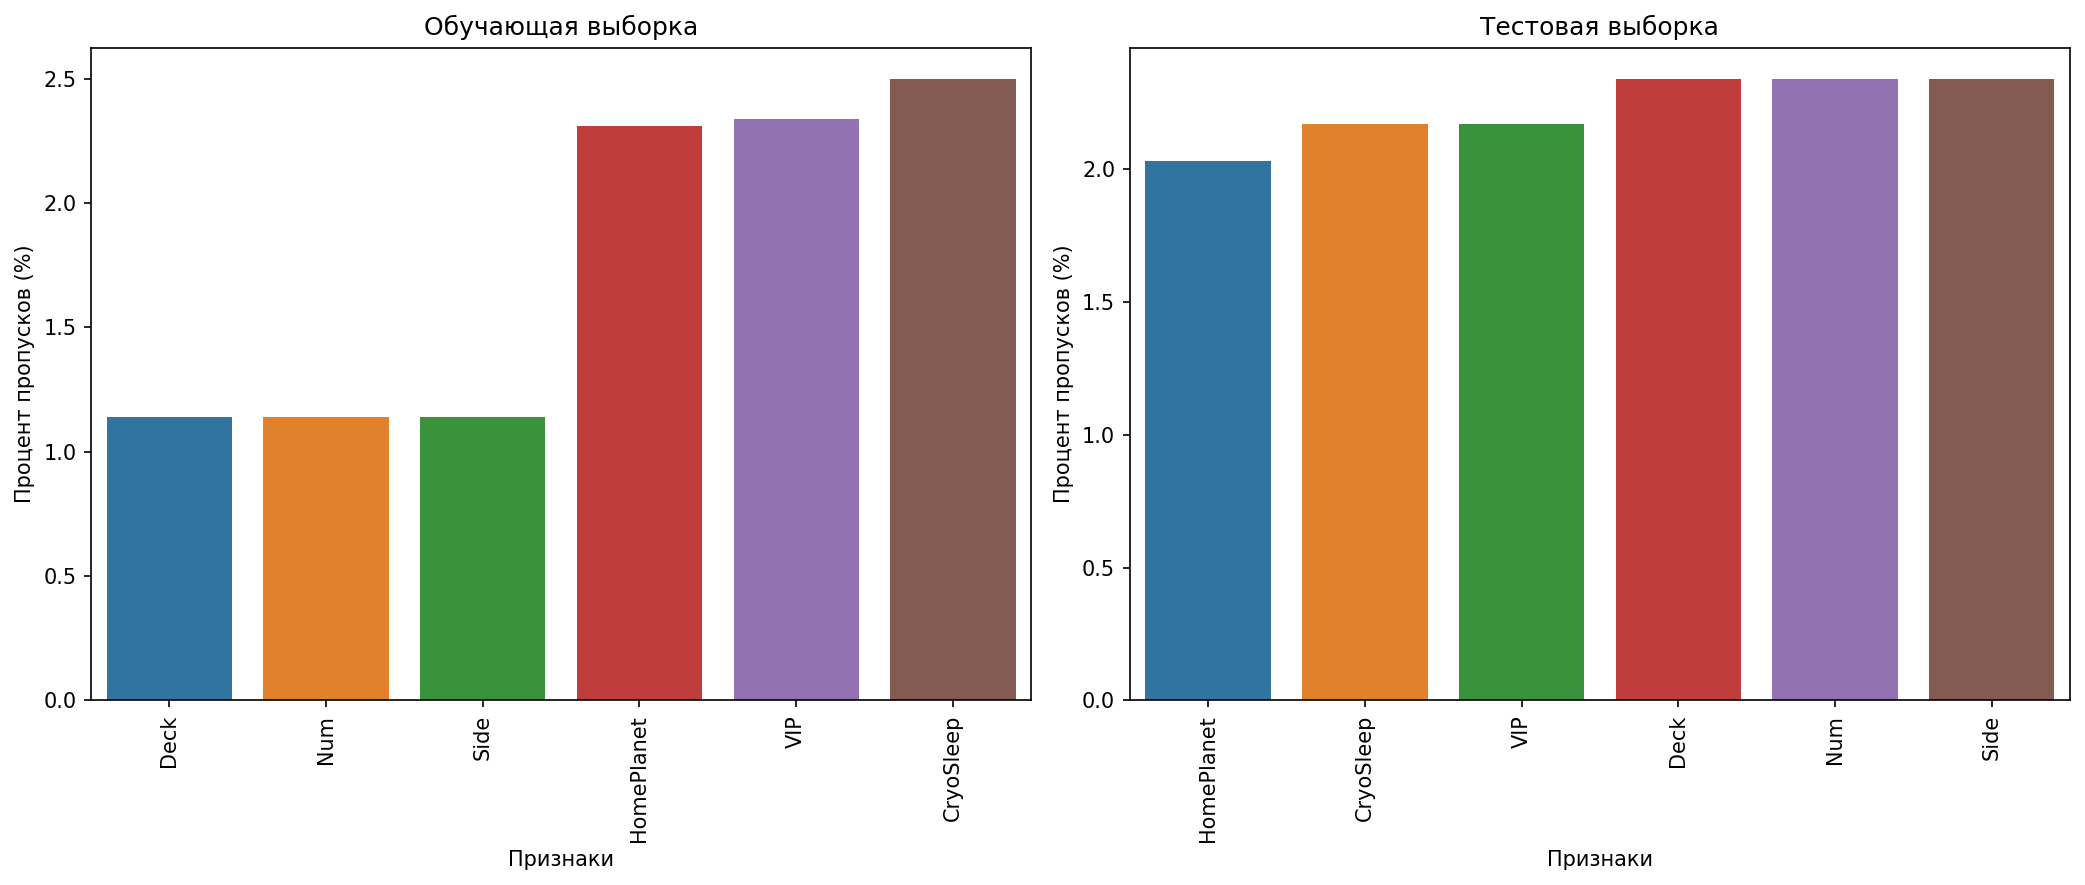

In [164]:
show_missing_data(df_train, df_test)

In [165]:
pd.crosstab(df_train['Deck'], df_train['HomePlanet'])

HomePlanet,Earth,Europa,Mars
Deck,,,
A,0,258,0
B,0,782,0
C,0,748,0
D,0,189,288
E,398,129,335
F,1624,0,1117
G,2525,0,0
T,0,4,0


- Жители с **Earth** занимают следующие палубы: _E, F, G_
- Жители с **Europa** занимают следующие палубы: _A, B, C, D, E, T_
- Жители с **Mars** занимают следующие палубы: _D, E, F_

In [166]:
deck_map = df_train.groupby("HomePlanet")["Deck"].apply(lambda x: x.mode()[0]).to_dict()
deck_mode = df_train["Deck"].mode()[0]

for df in [df_train, df_test]:
    df["Deck"] = df["Deck"].fillna(df["HomePlanet"].map(deck_map))
    df["Deck"] = df["Deck"].fillna(deck_mode)

`Side` заполняется самым популярным значением из выборки.

In [167]:
side_mode = df["Side"].mode()[0]

for df in [df_train, df_test]:
    df["Side"] = df["Side"].fillna(side_mode)

In [168]:
df_train.groupby("Deck")["Num"].agg(
    Min_num = "min",
    Median_num = "median",
    Max_num = "max",
    Count_num = "count"
)

,Min_num,Median_num,Max_num,Count_num
Deck,,,,
A,0.0,53.0,107.0,262
B,0.0,166.0,353.0,796
C,0.0,163.0,342.0,761
D,0.0,137.0,295.0,487
E,0.0,302.0,608.0,885
F,0.0,933.0,1894.0,2811
G,0.0,746.0,1508.0,2587
T,0.0,2.0,3.0,5


Как видно из сводной таблицы выше глобальную медиану `Num` брать **нельзя**, она некорректна для палуб A, B, C, D и T, так как выходит далеко за пределы их реального диапазона кают. Нужно взять медиану конкретной палубы `Deck`, чтобы сохранить положение каюты на корабле.

In [169]:
deck_num_map = df_train.dropna(subset=["Num"]).groupby("Deck")["Num"].median().to_dict()
Num_median = df_train["Num"].median()

for df in [df_train, df_test]:
    df["Num"] = df["Num"].fillna(df["Deck"].map(deck_num_map))
    df["Num"] = df["Num"].fillna(Num_median)

#### `HomePlanet`

Признак `HomePlanet` тесно связан с признаком `Group`. Выше через `crosstab` мы увидели, что есть привязка палубы `Deck` к `HomePlanet`

In [170]:
HP_group_map = df_train.dropna(subset=["HomePlanet"]).groupby("Group")["HomePlanet"].first().to_dict()
HP_deck_map = df_train.dropna(subset=["HomePlanet"]).groupby("Deck")["HomePlanet"].first().to_dict()

for df in [df_train, df_test]:
    df["HomePlanet"] = df["HomePlanet"].fillna(df["Group"].map(HP_group_map))
    df["HomePlanet"] = df["HomePlanet"].fillna(df["Deck"].map(HP_deck_map))

#### `VIP`

Признак `VIP` связан с группой пассажиров `Group`, однако во избежание утечки данных нужно работать только с тестовой выборкой.

In [171]:
group_vip_map = df_train.dropna(subset=["VIP"]).groupby("Group")["VIP"].first().to_dict()

for df in [df_train, df_test]:
    df["VIP"] = df["VIP"].fillna(df["Group"].map(group_vip_map))

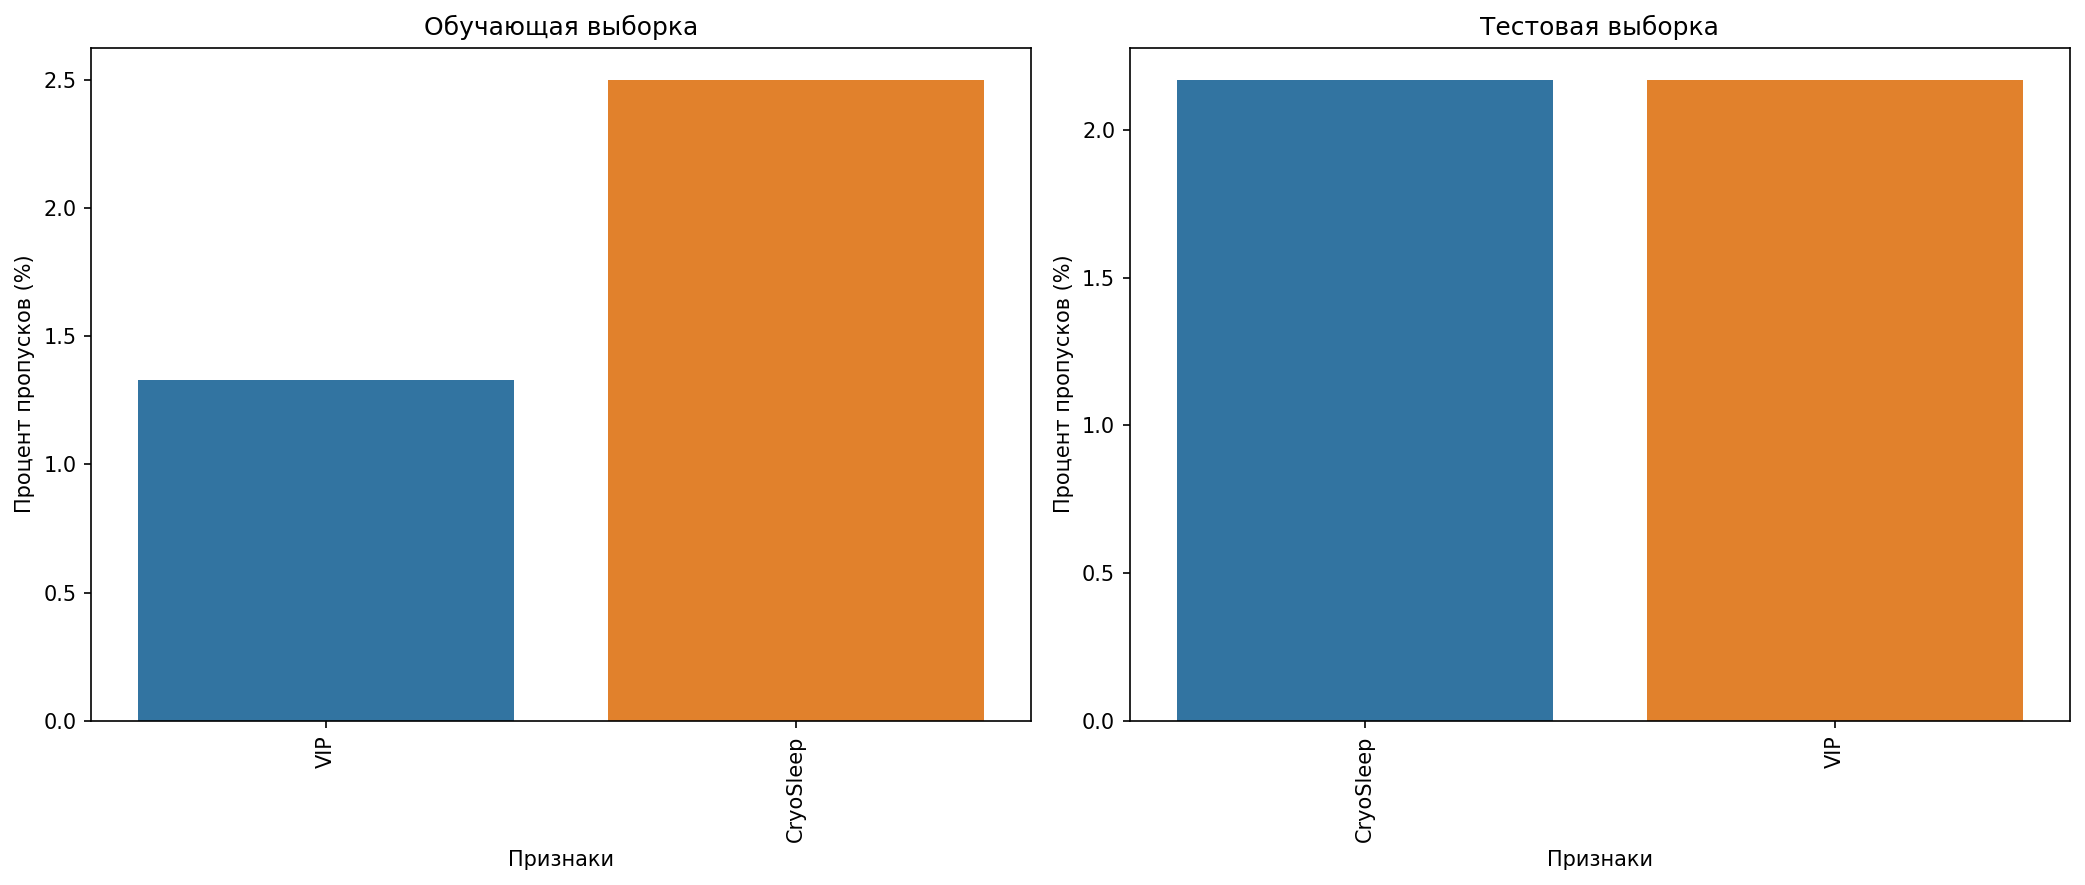

In [172]:
show_missing_data(df_train, df_test)

In [173]:
pd.crosstab(df_train['HomePlanet'], df_train['VIP'])

VIP,False,True
HomePlanet,,
Earth,4653,2
Europa,2019,132
Mars,1706,65


Можно уверенно сказать, что пассажиры с планеты "Earth" **не берут VIP**

In [174]:
df_train.dropna(subset=["VIP"]).groupby("Family_size")["VIP"].mean()

Family_size
1.0    0.020094
2.0    0.034541
3.0    0.021253
4.0    0.030899
5.0    0.019512
6.0    0.009259
7.0         0.0
8.0         0.0
Name: VIP, dtype: object

Пассажиры, которые состоят в группах с 7 и более человек, **не берут VIP** 

In [175]:
VIP_mode = df_train["VIP"].mode()[0]

for df in [df_train, df_test]:
    df.loc[df["VIP"].isna() & (df["Family_size"] >= 7), "VIP"] = False
    df.loc[(df["VIP"].isna()) & (df["HomePlanet"] == "Earth"), "VIP"] = False
    df["VIP"] = df["VIP"].fillna(VIP_mode)

C:\Users\egoro\AppData\Local\Temp\ipykernel_13876\1203237505.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["VIP"] = df["VIP"].fillna(VIP_mode)
C:\Users\egoro\AppData\Local\Temp\ipykernel_13876\1203237505.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["VIP"] = df["VIP"].fillna(VIP_mode)


#### `CryoSleep`

Признак `CryoSleep` заполняется исходя из той же логики, что мы использовали ранее: человек во сне не мог тратить деньги `TotalSpend` и наоборот.

In [176]:
for df in [df_train, df_test]:
    df.loc[(df["TotalSpend"] > 0) & df["CryoSleep"].isna(),"CryoSleep"] = False
    df.loc[(df["TotalSpend"] == 0) & df["CryoSleep"].isna(),"CryoSleep"] = True

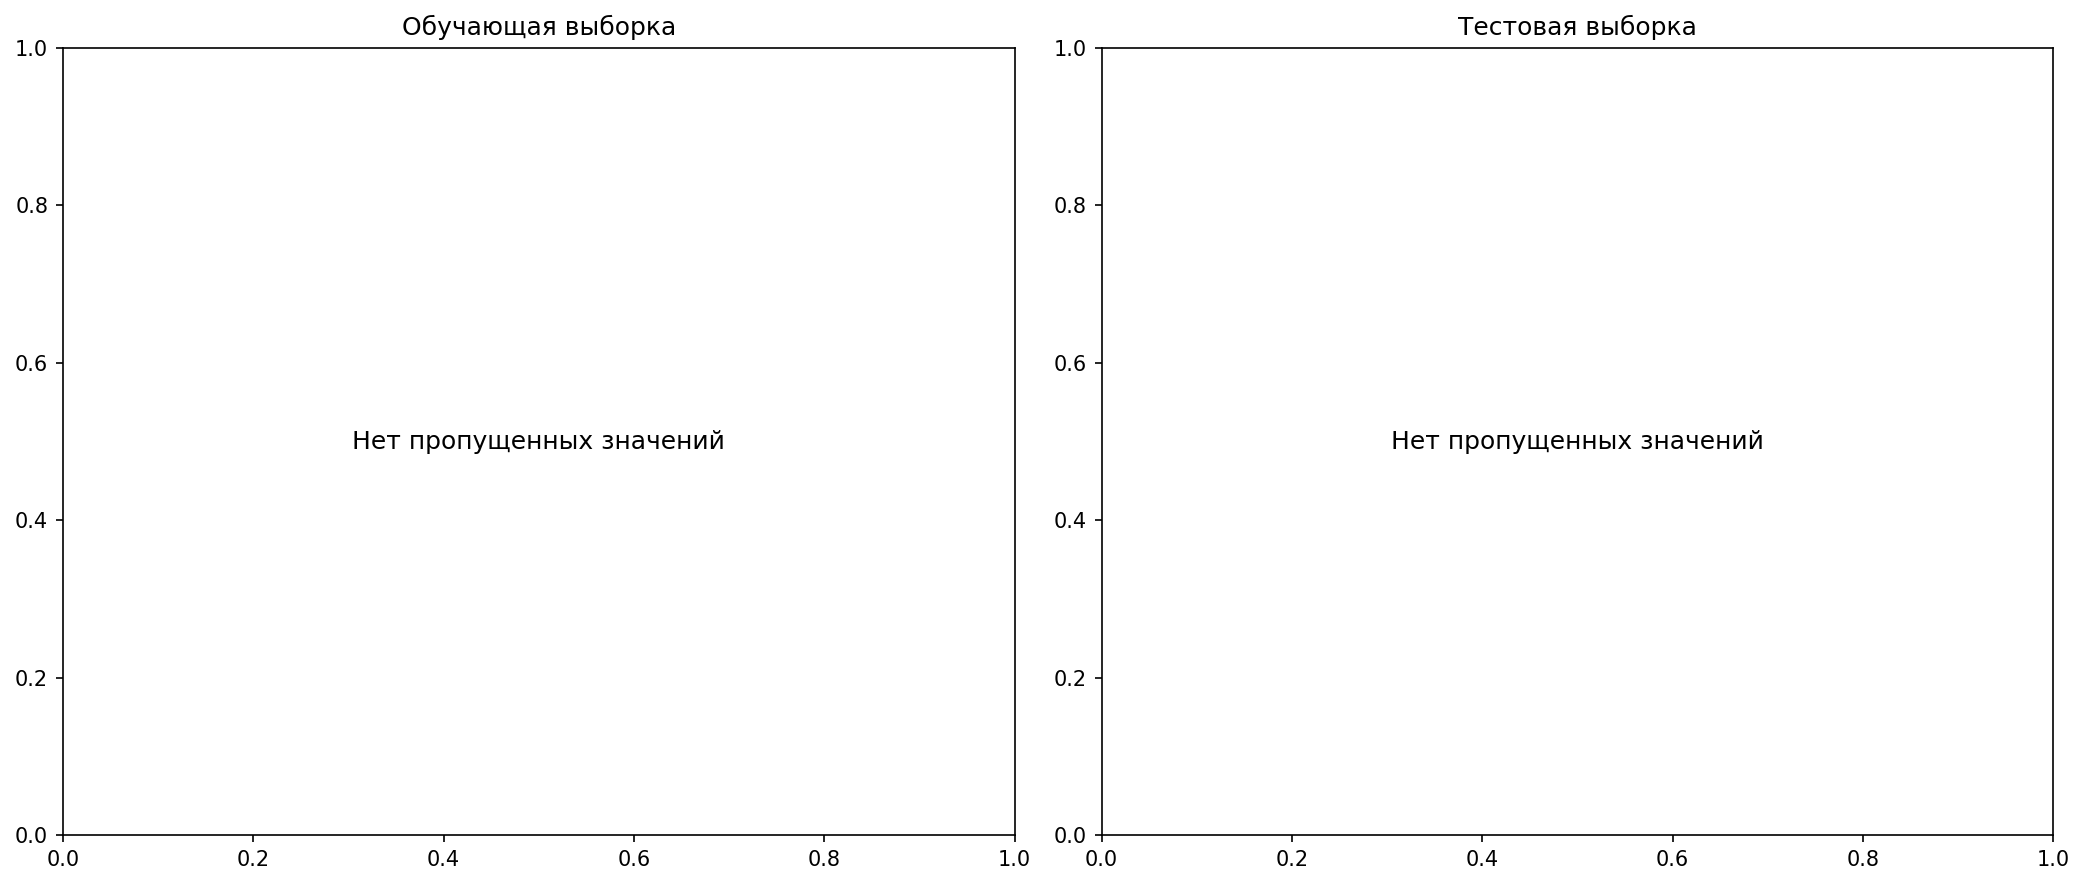

In [177]:
show_missing_data(df_train, df_test)

### Prerpocessing

In [178]:
df_train.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP',
       'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Transported', 'Group', 'TotalSpend', 'Family_size', 'Deck', 'Num',
       'Side'],
      dtype='object')

In [179]:
test_ID = df_test["PassengerId"]

for df in [df_train, df_test]:
    df.drop(["PassengerId", "TotalSpend", "Group"], axis=1, inplace=True)